In [8]:
import pandas as pd
import numpy as np

data = pd.read_csv("creditcard.csv")
legit_sample = data[data["Class"] == 0].sample(200, random_state=42)
fraud_sample = data[data["Class"] == 1]

sample_data = pd.concat([legit_sample, fraud_sample], axis=0)
sample_data = sample_data.sample(frac=1, random_state=42)

sample_data.to_csv("sample_transactions.csv", index=False)
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
data.tail()


In [ ]:
data.shape

In [ ]:
print(f"no. of rows: {data.shape[0]}")
print(f"no. of cols: {data.shape[1]}")

In [ ]:
data.info

In [ ]:
data.isnull().sum()


In [2]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
data[ ['Time', 'Amount'] ]= sc.fit_transform(pd.DataFrame( data [ ['Time', 'Amount'] ] ) )

In [ ]:
data.head()

In [ ]:
data.shape

In [ ]:
data.duplicated().any()

In [3]:
data = data.drop_duplicates()

In [ ]:
data.shape


In [ ]:
data["Class"].value_counts()

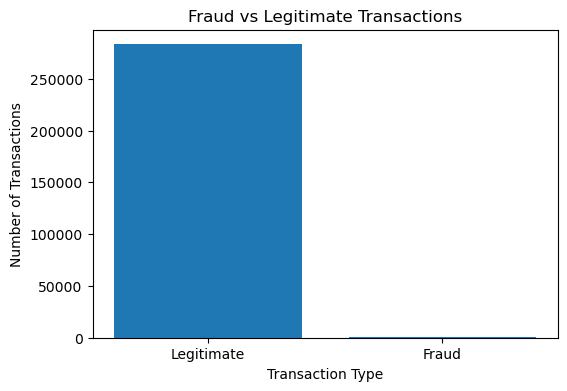

In [4]:
import matplotlib.pyplot as plt

class_counts = data['Class'].value_counts()
labels = ['Legitimate', 'Fraud']
counts = [class_counts[0], class_counts[1]]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts)
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')

plt.show()

In [5]:
# X features and y targets 
X = data.drop("Class", axis=1)
y = data["Class"]
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=42,
                                                    stratify=y)
print(f"Training data Class values info: \n{y_train.value_counts()}")
print(f"Testing data Class values info: \n{y_test.value_counts()}")

Training data Class values info: 
Class
0    226602
1       378
Name: count, dtype: int64
Testing data Class values info: 
Class
0    56651
1       95
Name: count, dtype: int64


In [ ]:
!pip install imbalanced-learn

Class
0    226602
1     45320
Name: count, dtype: int64


In [6]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Apply SMOTE only on training data
smote = SMOTE(sampling_strategy=0.02, random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)

model.fit(X_train_resampled, y_train_resampled)

# Predict on original test data
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9993303492757198
Confusion Matrix:
[[56634    17]
 [   21    74]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.81      0.78      0.80        95

    accuracy                           1.00     56746
   macro avg       0.91      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [25]:
import joblib

joblib.dump(model, "fraud_model.pkl")
joblib.dump(sc, "scaler.pkl")

['scaler.pkl']